In [2]:
# her importer jeg bibloteker og loader vores utils fil som defenerer vores features
# Vi importerer alle de biblioteker vi skal bruge. TabPFNClassifier er selve modellen, shap bruges til at forklare den, matplotlib til at gemme figuren, og Utils giver os adgang til vores fælles funktioner og feature-liste

import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/Users/mariusschonberg/Desktop/Speciale/code/models")
from Utils import FEATURES, load_shots, _encode_features, _impute_with_train_median, _pooled_auc, _pooled_ll
import matplotlib.pyplot as plt


In [3]:
# load data
#Vi læser den samlede CSV-fil med alle 5056 skud fra alle 192 kampe i Superliga 2024/25. Vi printer antal skud og målrate som en hurtig sanity check.


df = pd.read_csv("/Users/mariusschonberg/Desktop/Speciale/outputs/outputs/all_matches_features_final.csv")
print(f"Skud i alt: {len(df)}")
print(f"Mål: {df['is_goal'].sum()} ({df['is_goal'].mean()*100:.1f}%)")

Skud i alt: 5056
Mål: 601 (11.9%)


In [4]:
#Vi gemmer navnene på de 15 features som en liste. Det er vigtigt at gøre dette her — før vi encoder — fordi _encode_features returnerer et numpy array uden kolonnenavne.

feature_names = df[FEATURES].columns.tolist()

In [5]:
# Vi konverterer vores feature-dataframe til et numpy array. Kategoriske kolonner som shot_body_part og play_pattern bliver label-encodet til tal. Alle numeriske kolonner sikres som float.
# forbered features — encode kategoriske variable og konverter til numpy array
X = _encode_features(df[FEATURES])
y = df["is_goal"].astype(int).to_numpy()

In [6]:
# 80/20 split — 80% til træning, 20% til test
# stratify=y sikrer samme andel mål i begge sæt
# random_state=42 sikrer reproducerbart split
#Vi deler data i 80% træning og 20% test med stratify=y så begge sæt har samme andel mål. random_state=42 sikrer at splittet er reproducerbart — det samme split bruges i alle vores modeller

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 4044, Test: 1012


In [7]:
# Imputer NaN med median fra træningsdata (forhindrer data-lækage)
# XGBoost kan håndtere NaN internt, men vi imputer for konsistens
#Vi fylder manglende værdier ud med medianen fra træningssættet. Vi bruger kun træningsdata til at beregne medianen for at undgå data-lækage — testdata må ikke påvirke præprocesseringen.

X_train, X_test = _impute_with_train_median(X_train, X_test)

In [8]:
# Initialiser TabPFN classifier
# Vi initialiserer TabPFN med fit_with_cache som aktiverer KV-cache og gør modellen hurtigere ved gentagne kald. Vi træner på de 3965 træningsskud. TabPFN er en transformer-baseret foundation model der ikke kræver hyperparameter-tuning

model = TabPFNClassifier(
    fit_mode="fit_with_cache",
    random_state=42
)

# Træn modellen
model.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
# Sandsynlighed for klasse 1 (mål)
# Vi beregner sandsynligheden for mål for hvert skud i testsettet. [:, 1] giver os klasse 1 (mål) sandsynlighederne.



y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
# Her sker det vigtige. shap.kmeans(X_train, 50) komprimerer de 3965 træningsskud ned til 50 repræsentative baggrundspunkter — 
# det gør beregningen meget hurtigere. KernelExplainer bruges fordi TabPFN ikke er et træ, så TreeExplainer ikke virker. 
# KernelExplainer er model-agnostisk og virker på alle modeller der kan kalde predict_proba. Vi beregner SHAP-værdier for de første 200 testskud — vi bruger ikke alle 5056 fordi KernelExplainer kalder modellen ~100 gange per skud, hvilket ville tage dage.

import shap
background = shap.kmeans(X_train, 50)
explainer = shap.KernelExplainer(model.predict_proba, background)
shap_values = explainer.shap_values(X_test[:200], nsamples=100)

  0%|          | 0/200 [00:00<?, ?it/s]

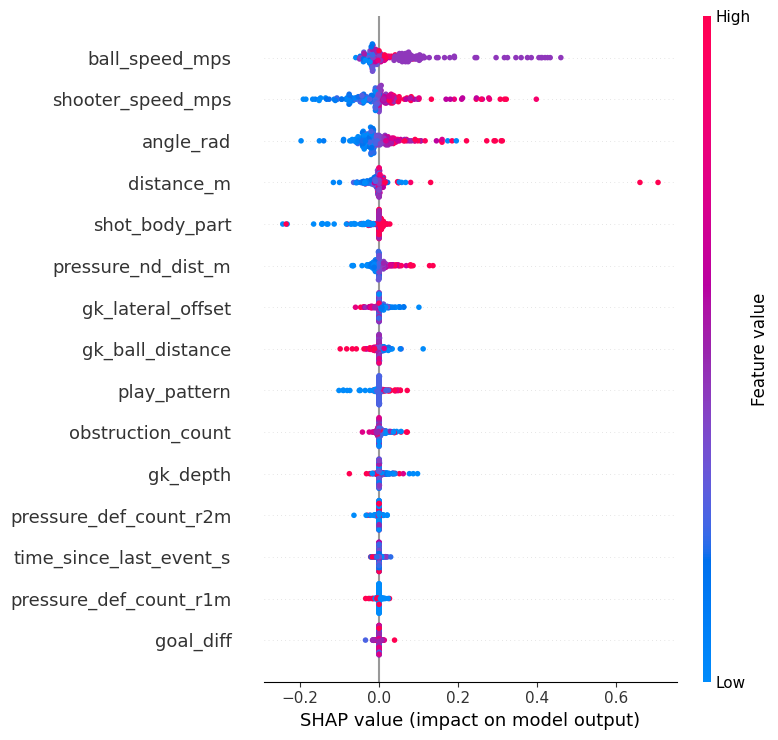

In [ ]:
# Cell 10 — bar plot
# Vi laver et bar plot der viser den gennemsnitlige absolutte SHAP-værdi per feature. shap_values[1] er SHAP-værdierne for klasse 1 (mål). show=False forhindrer at plottet vises før vi har gemt det. Vi gemmer figuren direkte i thesis/figures/ så den er klar til Overleaf.
# Cell 10 — bar plot

shap.summary_plot(shap_values[:, :, 1], X_test[:200], feature_names=feature_names, show=False)
plt.savefig("/Users/mariusschonberg/Desktop/Speciale/thesis/figures/shap_tabpfn_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Mean absolut SHAP-værdi per feature — rangordning fra vigtigst til mindst vigtig
vals = np.abs(shap_values[:, :, 1]).mean(axis=0)
top = pd.Series(vals, index=feature_names).sort_values(ascending=False)

print("SHAP feature importance ranking (TabPFN):")
for i, (feat, val) in enumerate(top.items(), 1):
    print(f"  {i:2d}. {feat:35s} {val:.4f}")
